# **Set up**

In [55]:
import os
import pandas as pd
import numpy as np

os.makedirs("outputs/maps", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)

cands = pd.read_excel("/Users/razzanramadhana/Documents/MAGANG/kopi-transit-geo/data/candidates.xlsx")
cands

,site_id,name,address,lat,lon,notes
0,S1,Kandidat A,Ruko sekitar MERR/UPN,-7.332194,112.789378,dekat arus pagi
1,S2,Kandidat B,Ruko sekitar UNAIR B,-7.273271,112.756361,dekat kos


In [56]:
import requests
from dotenv import load_dotenv

load_dotenv()
ORS_API_KEY = os.getenv("ORS_API_KEY")

def ors_isochrone(lat, lon, profile, ranges_sec):
    url = f"https://api.openrouteservice.org/v2/isochrones/{profile}"
    headers = {"Authorization": ORS_API_KEY, "Content-Type": "application/json"}
    body = {
        "locations": [[lon, lat]],
        "range": ranges_sec,  # detik
        "attributes": ["total_pop"]  # optional, bisa kosong
    }
    r = requests.post(url, json=body, headers=headers, timeout=60)
    r.raise_for_status()
    return r.json()


# **Convert isochrone ke GeoDataFrame**

In [57]:
import geopandas as gpd
from shapely.geometry import shape

def isochrone_to_gdf(iso_json, site_id):
    feats = iso_json["features"]
    rows = []
    for f in feats:
        geom = shape(f["geometry"])
        rng  = f["properties"]["value"]  # seconds
        rows.append({"site_id": site_id, "range_sec": rng, "geometry": geom})
    gdf = gpd.GeoDataFrame(rows, crs="EPSG:4326")
    return gdf

iso_all = []

for _, row in cands.iterrows():
    lat, lon = row["lat"], row["lon"]
    # 5 menit jalan kaki = 300s; 10 menit motor/bersepeda = 600s
    iso_walk = ors_isochrone(lat, lon, profile="foot-walking", ranges_sec=[300])
    iso_drive = ors_isochrone(lat, lon, profile="cycling-road", ranges_sec=[600])

    gdf_w = isochrone_to_gdf(iso_walk, row["site_id"])
    gdf_d = isochrone_to_gdf(iso_drive, row["site_id"])

    gdf_w["mode"] = "walk_5min"
    gdf_d["mode"] = "motor_10min"

    iso_all.append(gdf_w)
    iso_all.append(gdf_d)

iso_gdf = pd.concat(iso_all, ignore_index=True)
iso_gdf


,site_id,range_sec,geometry,mode
0,S1,300.0,"POLYGON ((112.78562 -7.33195, 112.7857 -7.3320...",walk_5min
1,S1,600.0,"POLYGON ((112.75065 -7.32973, 112.75173 -7.331...",motor_10min
2,S2,300.0,"POLYGON ((112.75385 -7.27194, 112.75383 -7.272...",walk_5min
3,S2,600.0,"POLYGON ((112.74195 -7.25558, 112.74006 -7.260...",motor_10min


# **Plot peta isochrone**

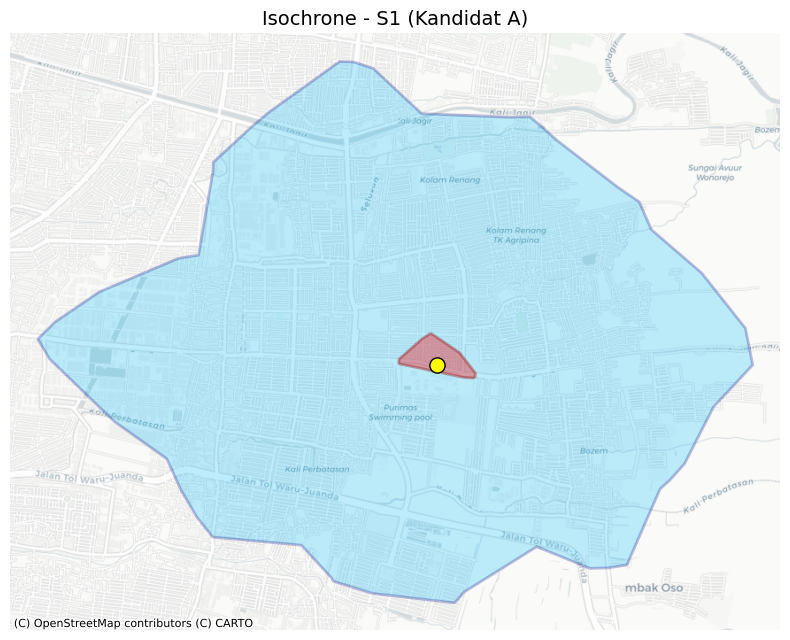

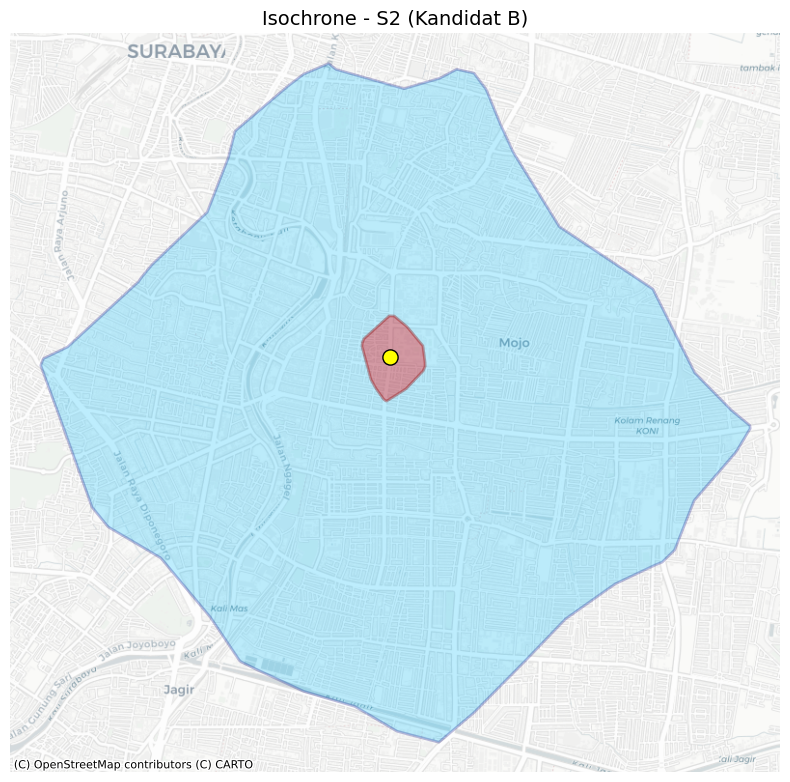

In [58]:
import matplotlib.pyplot as plt
import contextily as ctx

# 1) CRS meter untuk basemap tiles
iso_m = iso_gdf.to_crs(epsg=3857)

# 2) bikin GeoDataFrame titik kandidat (biar ada marker lokasi)
cand_pts = gpd.GeoDataFrame(
    cands.copy(),
    geometry=gpd.points_from_xy(cands["lon"], cands["lat"]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

for sid in iso_m["site_id"].unique():
    fig, ax = plt.subplots(figsize=(8, 8))

    sub = iso_m[iso_m["site_id"] == sid]
    motor = sub[sub["mode"]=="motor_10min"]
    walk  = sub[sub["mode"]=="walk_5min"]

    # 3) Plot polygon dengan warna jelas
    motor.plot(ax=ax, alpha=0.25, edgecolor="navy", linewidth=2, facecolor="deepskyblue")
    walk.plot(ax=ax,  alpha=0.35, edgecolor="darkred", linewidth=2, facecolor="red")

    # 4) Plot titik kandidat
    p = cand_pts[cand_pts["site_id"] == sid]
    p.plot(ax=ax, color="yellow", edgecolor="black", markersize=120, zorder=5)

    # 5) Zoom ke bounds motor isochrone (biar nggak kepotong / nggak terlalu jauh)
    minx, miny, maxx, maxy = motor.total_bounds
    pad = 300  # meter, atur 200-600 sesuai selera
    ax.set_xlim(minx - pad, maxx + pad)
    ax.set_ylim(miny - pad, maxy + pad)

    # 6) Tambahkan basemap (butuh internet untuk ambil tile)
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)  # clean untuk laporan

    name = cands.loc[cands["site_id"]==sid, "name"].values[0]
    ax.set_title(f"Isochrone - {sid} ({name})", fontsize=14)
    ax.axis("off")

    out = f"outputs/maps/isochrone_{sid}_basemap.png"
    plt.tight_layout()
    plt.savefig(out, dpi=250, bbox_inches="tight")
    plt.show()


# **Supply and Deman Checking**

## **Fungsi hitung POI dalam polygon (OSMnx)**

In [59]:
import osmnx as ox

ox.settings.use_cache = True
ox.settings.log_console = False

def count_pois_within_polygon(polygon_wgs84, tags):
    try:
        gdf = ox.features_from_polygon(polygon_wgs84, tags=tags)
        return len(gdf), gdf
    except ox._errors.InsufficientResponseError:
        # tidak ada fitur yang match → return kosong
        empty = gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
        return 0, empty

# definisi tags (OSM)
TAGS_DEMAND = {
    "amenity": ["university", "college", "school"],
    "office": True
}
TAGS_HOUSING = {
    "building": ["dormitory", "apartments", "residential"],
    "tourism": ["hostel"]
}
TAGS_COFFEE = {
    "amenity": ["cafe"],
    "shop": ["coffee"]
}


## **Hitung demand & kompetitor per kandidat**

In [60]:
iso_wgs = iso_gdf.copy()  # EPSG:4326

rows = []
poi_layers = {}  # simpan gdf POI buat mapping

for sid in cands["site_id"].unique():
    poly_market = iso_wgs[(iso_wgs["site_id"]==sid) & (iso_wgs["mode"]=="motor_10min")].iloc[0].geometry

    n_demand, g_demand = count_pois_within_polygon(poly_market, TAGS_DEMAND)
    n_housing, g_housing = count_pois_within_polygon(poly_market, TAGS_HOUSING)
    n_coffee, g_coffee = count_pois_within_polygon(poly_market, TAGS_COFFEE)

    rows.append({
        "site_id": sid,
        "demand_edu_office": n_demand,
        "housing_proxy": n_housing,
        "competitors_proxy": n_coffee,
    })

    poi_layers[(sid, "demand")] = g_demand
    poi_layers[(sid, "housing")] = g_housing
    poi_layers[(sid, "coffee")] = g_coffee

summary = pd.DataFrame(rows).merge(cands[["site_id","name","address"]], on="site_id")
summary


,site_id,demand_edu_office,housing_proxy,competitors_proxy,name,address
0,S1,133,21,13,Kandidat A,Ruko sekitar MERR/UPN
1,S2,406,34,125,Kandidat B,Ruko sekitar UNAIR B


## **Pemetaan Demand**

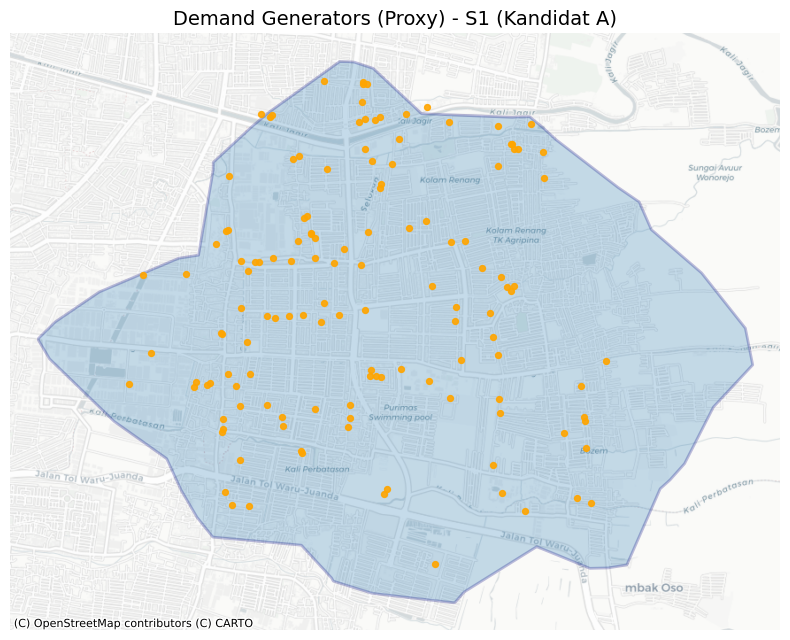

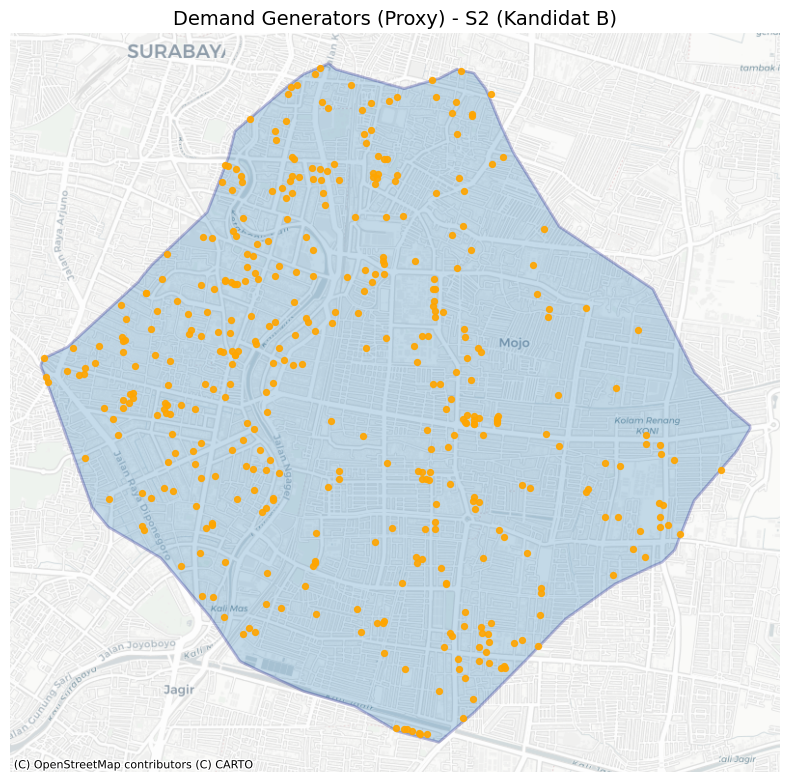

In [61]:
def to_point_gdf(osm_gdf):
    g = osm_gdf.copy()
    # centroid lebih aman kalau dihitung di CRS meter
    g = g.to_crs(3857)
    g["geometry"] = g["geometry"].centroid
    return g.to_crs(4326)

for sid in cands["site_id"].unique():
    fig, ax = plt.subplots(figsize=(8, 8))

    # polygon market (motor_10min)
    poly = iso_gdf[(iso_gdf["site_id"]==sid) & (iso_gdf["mode"]=="motor_10min")].to_crs(3857)
    poly.plot(ax=ax, alpha=0.25, edgecolor="navy", linewidth=2)

    # demand points
    g_demand = poi_layers[(sid, "demand")]
    if len(g_demand) > 0:
        g_demand_pts = g_demand.to_crs(3857).copy()
        g_demand_pts["geometry"] = g_demand_pts["geometry"].centroid
        g_demand_pts.plot(ax=ax, markersize=18, color="orange", alpha=0.9, zorder=5)

    # auto-zoom ke polygon
    minx, miny, maxx, maxy = poly.total_bounds
    pad = 300  # meter (atur 200-600 sesuai selera)
    ax.set_xlim(minx - pad, maxx + pad)
    ax.set_ylim(miny - pad, maxy + pad)

    # basemap (butuh internet untuk ambil tiles)
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

    name = cands.loc[cands["site_id"]==sid, "name"].values[0]
    ax.set_title(f"Demand Generators (Proxy) - {sid} ({name})", fontsize=14)
    ax.axis("off")

    out = f"outputs/maps/demand_{sid}_basemap.png"
    plt.tight_layout()
    plt.savefig(out, dpi=250, bbox_inches="tight")
    plt.show()


## **Pemetaan Kompetitor**

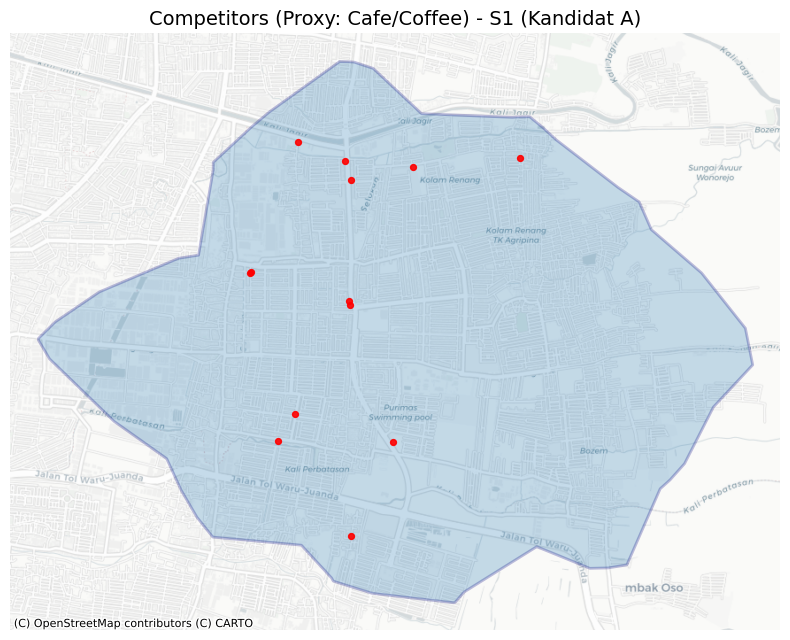

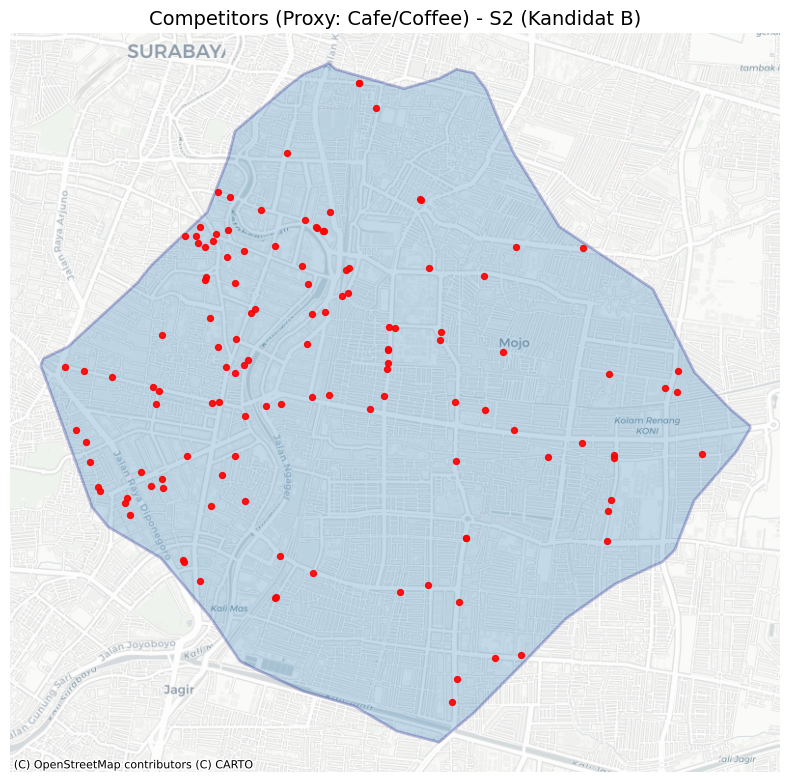

In [62]:
for sid in cands["site_id"].unique():
    fig, ax = plt.subplots(figsize=(8, 8))

    # Polygon market (motor_10min)
    poly = iso_gdf[(iso_gdf["site_id"]==sid) & (iso_gdf["mode"]=="motor_10min")].to_crs(3857)
    poly.plot(ax=ax, alpha=0.25, edgecolor="navy", linewidth=2)

    # Competitor points (cafe/coffee)
    g_coffee = poi_layers[(sid, "coffee")]
    if len(g_coffee) > 0:
        g_coffee_pts = g_coffee.to_crs(3857).copy()
        g_coffee_pts["geometry"] = g_coffee_pts["geometry"].centroid  # aman untuk polygon/line
        g_coffee_pts.plot(ax=ax, markersize=18, color="red", alpha=0.9, zorder=5)

    # Auto zoom ke bounds polygon
    minx, miny, maxx, maxy = poly.total_bounds
    pad = 300  # meter (atur 200-600 sesuai selera)
    ax.set_xlim(minx - pad, maxx + pad)
    ax.set_ylim(miny - pad, maxy + pad)

    # Basemap (butuh internet untuk ambil tiles)
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

    name = cands.loc[cands["site_id"]==sid, "name"].values[0]
    ax.set_title(f"Competitors (Proxy: Cafe/Coffee) - {sid} ({name})", fontsize=14)
    ax.axis("off")

    out = f"outputs/maps/competitors_{sid}_basemap.png"
    plt.tight_layout()
    plt.savefig(out, dpi=250, bbox_inches="tight")
    plt.show()


## **Digital Footprint “Popular Times” (cek manual ke gmaps)**

## A) Cara Mengambil Bukti “Popular Times” dari Google Maps (Manual)

Langkah berikut dilakukan untuk **setiap kandidat lokasi** (S1, S2, S3):

### 1. Buka Google Maps
- Akses melalui browser desktop atau aplikasi mobile.

### 2. Cari Lokasi Kandidat
- Masukkan **nama lokasi atau alamat kandidat** sesuai hasil scouting.

### 3. Pastikan Membuka *Place Profile*
- Klik lokasi hingga muncul **panel informasi tempat** (*place profile*).

> **Catatan:**  
> Jika kandidat merupakan **ruko kosong** dan **tidak memiliki place profile**:
> - Cari **bisnis terdekat yang relevan** (misalnya: *Indomaret, Alfamart, kafe, restoran*).
> - Pastikan bisnis tersebut berada dalam **radius ±100–300 meter** dari kandidat.
> - Bisnis ini digunakan sebagai **proxy keramaian area**.

### 4. Temukan Bagian “Popular Times / Jam Ramai”
- Scroll panel informasi hingga menemukan **grafik batang Popular Times**.
- Pastikan grafik menampilkan aktivitas per jam.

### 5. Ambil Screenshot Jam Kritis
Ambil screenshot yang **jelas dan terbaca** untuk:
- **Pagi hari:** fokus jam **08.00 – 10.00**
- **Siang hari:** fokus jam **12.00 – 13.00**

> Pastikan screenshot menampilkan:
> - Nama tempat (proxy)
> - Lokasi/jalan
> - Grafik Popular Times

### 6. Simpan File dengan Penamaan Terstruktur

In [63]:
import pandas as pd

popular = pd.DataFrame({
    "site_id": cands["site_id"],
    "popular_times_place_used": [None]*len(cands),  # nama tempat yang kamu pakai (proxy)
    "busy_morning_08_10": [None]*len(cands),        # True/False
    "busy_lunch_12_13":   [None]*len(cands),        # True/False
    "notes":              [None]*len(cands),
})
popular


,site_id,popular_times_place_used,busy_morning_08_10,busy_lunch_12_13,notes
0,S1,None,None,None,None
1,S2,None,None,None,None


In [64]:
popular.loc[popular.site_id=="S1", "popular_times_place_used"] = "Indomaret MERR"
popular.loc[popular.site_id=="S1", "busy_morning_08_10"] = True
popular.loc[popular.site_id=="S1", "busy_lunch_12_13"] = True
popular.loc[popular.site_id=="S1", "notes"] = "Ramai pagi & lunch, cocok grab-and-go"

popular.loc[popular.site_id=="S2", "popular_times_place_used"] = "Warung X dekat Unair B"
popular.loc[popular.site_id=="S2", "busy_morning_08_10"] = True
popular.loc[popular.site_id=="S2", "busy_lunch_12_13"] = False
popular.loc[popular.site_id=="S2", "notes"] = "Ramai pagi tapi lunch kurang"

popular

,site_id,popular_times_place_used,busy_morning_08_10,busy_lunch_12_13,notes
0,S1,Indomaret MERR,True,True,"Ramai pagi & lunch, cocok grab-and-go"
1,S2,Warung X dekat Unair B,True,False,Ramai pagi tapi lunch kurang


## **Road Density (akses jalan)**

In [65]:
from shapely.geometry import Polygon, MultiPolygon

def road_density_km_per_km2_safe(polygon_wgs84, center_lat=None, center_lon=None,
                                buffer_m=150, fallback_dist_m=1200):
    """
    Hitung road density (km jalan per km2).
    - Coba graph_from_polygon dulu.
    - Kalau gagal (no nodes), buffer polygon dan coba lagi.
    - Kalau masih gagal, fallback ke graph_from_point (radius).
    """

    # 1) pastikan polygon valid + buffer kecil (di CRS meter)
    poly_s = gpd.GeoSeries([polygon_wgs84], crs=4326).to_crs(3857)
    poly_m = poly_s.iloc[0]

    # fix invalid geometry
    if not poly_m.is_valid:
        poly_m = poly_m.buffer(0)

    # buffer supaya nangkep jalan di tepi
    poly_m_buf = poly_m.buffer(buffer_m)

    # balik ke WGS84 untuk OSMnx
    poly_buf_wgs = gpd.GeoSeries([poly_m_buf], crs=3857).to_crs(4326).iloc[0]

    # helper hitung density
    def _density_from_graph(G, poly_meter):
        edges = ox.graph_to_gdfs(G, nodes=False, edges=True)
        edges_m = edges.to_crs(3857)
        total_km = edges_m["length"].sum() / 1000.0
        area_km2 = poly_meter.area / 1_000_000.0
        return float(total_km / area_km2)

    # 2) coba polygon buffered
    try:
        G = ox.graph_from_polygon(poly_buf_wgs, network_type="drive", simplify=True)
        return _density_from_graph(G, poly_m_buf)
    except Exception as e:
        # 3) fallback: graph_from_point
        if center_lat is None or center_lon is None:
            raise ValueError(
                "Polygon tidak menghasilkan graph jalan. "
                "Isi center_lat/center_lon untuk fallback graph_from_point."
            ) from e

        G = ox.graph_from_point((center_lat, center_lon),
                                dist=fallback_dist_m,
                                network_type="drive",
                                simplify=True)
        # area fallback: pakai lingkaran radius fallback_dist_m
        circle_area_km2 = (3.14159 * (fallback_dist_m**2)) / 1_000_000.0
        edges = ox.graph_to_gdfs(G, nodes=False, edges=True).to_crs(3857)
        total_km = edges["length"].sum() / 1000.0
        return float(total_km / circle_area_km2)


road_rows = []

for _, r in cands.iterrows():
    sid = r["site_id"]
    poly_market = iso_gdf[(iso_gdf["site_id"]==sid) & (iso_gdf["mode"]=="motor_10min")].iloc[0].geometry

    dens = road_density_km_per_km2_safe(
        poly_market,
        center_lat=r["lat"],
        center_lon=r["lon"],
        buffer_m=200,          # coba 150-300
        fallback_dist_m=1200   # radius fallback
    )

    road_rows.append({"site_id": sid, "road_density": dens})

roads = pd.DataFrame(road_rows)
roads

roads = pd.DataFrame(road_rows)
summary2 = summary.merge(roads, on="site_id")
summary2

,site_id,demand_edu_office,housing_proxy,competitors_proxy,name,address,road_density
0,S1,133,21,13,Kandidat A,Ruko sekitar MERR/UPN,24.739328
1,S2,406,34,125,Kandidat B,Ruko sekitar UNAIR B,26.904483


## **Normalisasi skor + bobot**

In [66]:
df = summary2.copy()

# fitur untuk "density kos/kampus"
df["demand_score_raw"] = df["demand_edu_office"] + df["housing_proxy"]

# kompetitor makin kecil makin bagus (nanti dibalik)
df["competitor_score_raw"] = df["competitors_proxy"]

# akses ojol (road density) makin besar makin bagus
df["access_score_raw"] = df["road_density"]

def minmax(x):
    if x.max() == x.min():
        return np.ones_like(x, dtype=float)
    return (x - x.min()) / (x.max() - x.min())

df["demand_score"] = minmax(df["demand_score_raw"])
df["access_score"] = minmax(df["access_score_raw"])

# kompetitor: dibalik
df["competitor_score"] = 1 - minmax(df["competitor_score_raw"])

# bobot
W_DEMAND = 0.40
W_COMP   = 0.30
W_ACCESS = 0.30

df["final_score"] = (
    W_DEMAND*df["demand_score"] +
    W_COMP*df["competitor_score"] +
    W_ACCESS*df["access_score"]
)

df = df.sort_values("final_score", ascending=False)
df[["site_id","name","demand_score_raw","competitors_proxy","road_density","final_score"]]


,site_id,name,demand_score_raw,competitors_proxy,road_density,final_score
1,S2,Kandidat B,440,125,26.904483,0.7
0,S1,Kandidat A,154,13,24.739328,0.3


- Kepadatan kos/kampus (40%) → gabung demand_edu_office + housing_proxy
- Minim kompetitor (30%) → kebalikan dari competitors_proxy (+ input direct competitor manual kalau kamu punya)
- Kemudahan akses ojol (30%) → proxy sederhana: kepadatan jalan utama di area (OSM road density) atau “jarak ke jalan utama” (lebih berat). Kita pakai road density (panjang jalan per km²) dalam polygon.